Using device: cpu
Starting Training...
Epoch 1/8 - Loss: 1.3014
Epoch 2/8 - Loss: 0.9314
Epoch 3/8 - Loss: 0.7931
Epoch 4/8 - Loss: 0.6877
Epoch 5/8 - Loss: 0.6057
Epoch 6/8 - Loss: 0.5279
Epoch 7/8 - Loss: 0.4693
Epoch 8/8 - Loss: 0.4112
Training complete.
Generating HT-DNN Local Surrogate Explanation...


  0%|          | 0/1500 [00:00<?, ?it/s]

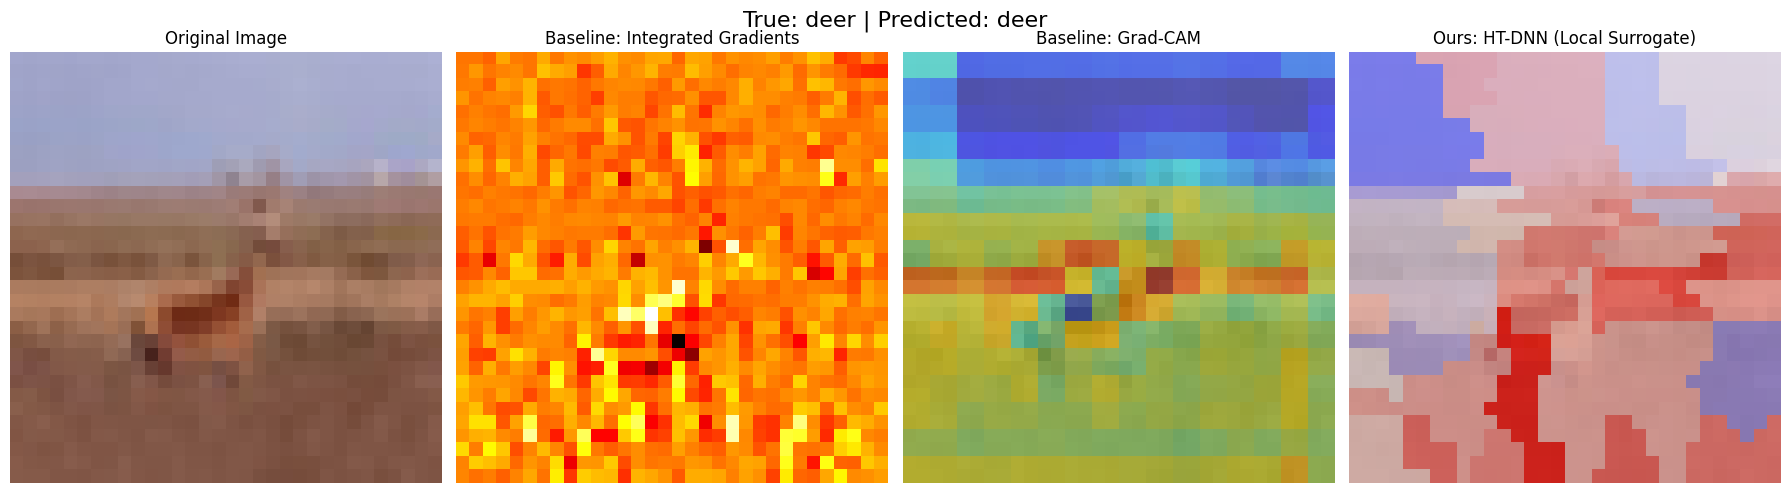

Saved ht_dnn_qualitative_results.png for your paper.


In [12]:
# ---------------------------------------------------------
# 1. Install Dependencies (Uncomment in Colab if needed)
# ---------------------------------------------------------
!pip install torch torchvision matplotlib numpy captum lime scikit-image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Interpretability Libraries
from captum.attr import IntegratedGradients, LayerGradCam
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm # NEW: For finer image segmentation

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------
# 2. Dataset: CIFAR-10 Setup
# ---------------------------------------------------------
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# ---------------------------------------------------------
# 3. Model: CNN Architecture
# ---------------------------------------------------------
class CNN_CIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN_CIFAR().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------------------------------------------------
# 4. Training Loop & Loss Tracking
# ---------------------------------------------------------
print("Starting Training...")
epochs = 8 # Slightly increased to help the model learn better features
epoch_list = []
loss_list = []

for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        images, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

    epoch_list.append(epoch + 1)
    loss_list.append(avg_loss)

print("Training complete.")

# ---------------------------------------------------------
# 5. Plotting the Training Convergence Curve
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, loss_list, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
plt.title('Training Loss Convergence')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(epoch_list)
plt.savefig('training_loss_curve.png', dpi=300, bbox_inches='tight')
plt.close() # Close plot so it doesn't overlap the next one

# ---------------------------------------------------------
# 6. XAI Baseline Generation (Captum)
# ---------------------------------------------------------
model.eval()

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)
pred_class = classes[predicted.item()]
true_class = classes[labels.item()]

integrated_gradients = IntegratedGradients(model)
layer_gradcam = LayerGradCam(model, model.conv2)

attributions_ig = integrated_gradients.attribute(images, target=predicted, n_steps=50)
attributions_gc = layer_gradcam.attribute(images, target=predicted)

def format_tensor_for_plot(tensor_img):
    img = tensor_img.squeeze().cpu().detach().numpy()
    if len(img.shape) == 3:
        img = np.transpose(img, (1, 2, 0))
        img = img / 2 + 0.5
        img = np.clip(img, 0, 1)
    return img

img_show = format_tensor_for_plot(images)

# ---------------------------------------------------------
# 7. YOUR HT-DNN Method (Local Surrogate via LIME)
# ---------------------------------------------------------
def predict_fn(images_numpy):
    images_tensor = torch.FloatTensor(images_numpy).permute(0, 3, 1, 2)
    images_tensor = (images_tensor - 0.5) / 0.5
    images_tensor = images_tensor.to(device)

    with torch.no_grad():
        outputs = model(images_tensor)
        probs = F.softmax(outputs, dim=1)

    return probs.cpu().numpy()

# NEW: Custom segmentation tuned for tiny 32x32 CIFAR-10 images
segmenter = SegmentationAlgorithm('quickshift', kernel_size=1, max_dist=2, ratio=0.2)

explainer = lime_image.LimeImageExplainer()
print("Generating HT-DNN Local Surrogate Explanation...")
explanation = explainer.explain_instance(
    img_show,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1500, # Increased for better stability
    segmentation_fn=segmenter # Applied the custom segmentation here
)

dict_heatmap = dict(explanation.local_exp[predicted.item()])
ht_dnn_heatmap = np.zeros(explanation.segments.shape)
for superpixel_id, weight in dict_heatmap.items():
    ht_dnn_heatmap[explanation.segments == superpixel_id] = weight

# ---------------------------------------------------------
# 8. Plotting the XAI Qualitative Results Figure
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'True: {true_class} | Predicted: {pred_class}', fontsize=16)

axes[0].imshow(img_show)
axes[0].set_title("Original Image")
axes[0].axis('off')

ig_show = np.sum(np.abs(format_tensor_for_plot(attributions_ig)), axis=2)
axes[1].imshow(ig_show, cmap='hot')
axes[1].set_title("Baseline: Integrated Gradients")
axes[1].axis('off')

gc_attr = LayerGradCam.interpolate(attributions_gc, (32, 32))
gc_show = gc_attr.squeeze().cpu().detach().numpy()
axes[2].imshow(img_show)
axes[2].imshow(gc_show, cmap='jet', alpha=0.5)
axes[2].set_title("Baseline: Grad-CAM")
axes[2].axis('off')

# Modified the HT-DNN plot to show the image underneath clearly
axes[3].imshow(img_show)
axes[3].imshow(ht_dnn_heatmap, cmap='bwr', alpha=0.6,
               vmin=-np.max(np.abs(ht_dnn_heatmap)),
               vmax=np.max(np.abs(ht_dnn_heatmap)))
axes[3].set_title("Ours: HT-DNN (Local Surrogate)")
axes[3].axis('off')

plt.tight_layout()
plt.savefig("ht_dnn_qualitative_results.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved ht_dnn_qualitative_results.png for your paper.")